In [266]:
import warnings 
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor

import matplotlib.pyplot as plt
import scipy.stats as stats

In [267]:
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


### Visualization: Distrubution Analysis

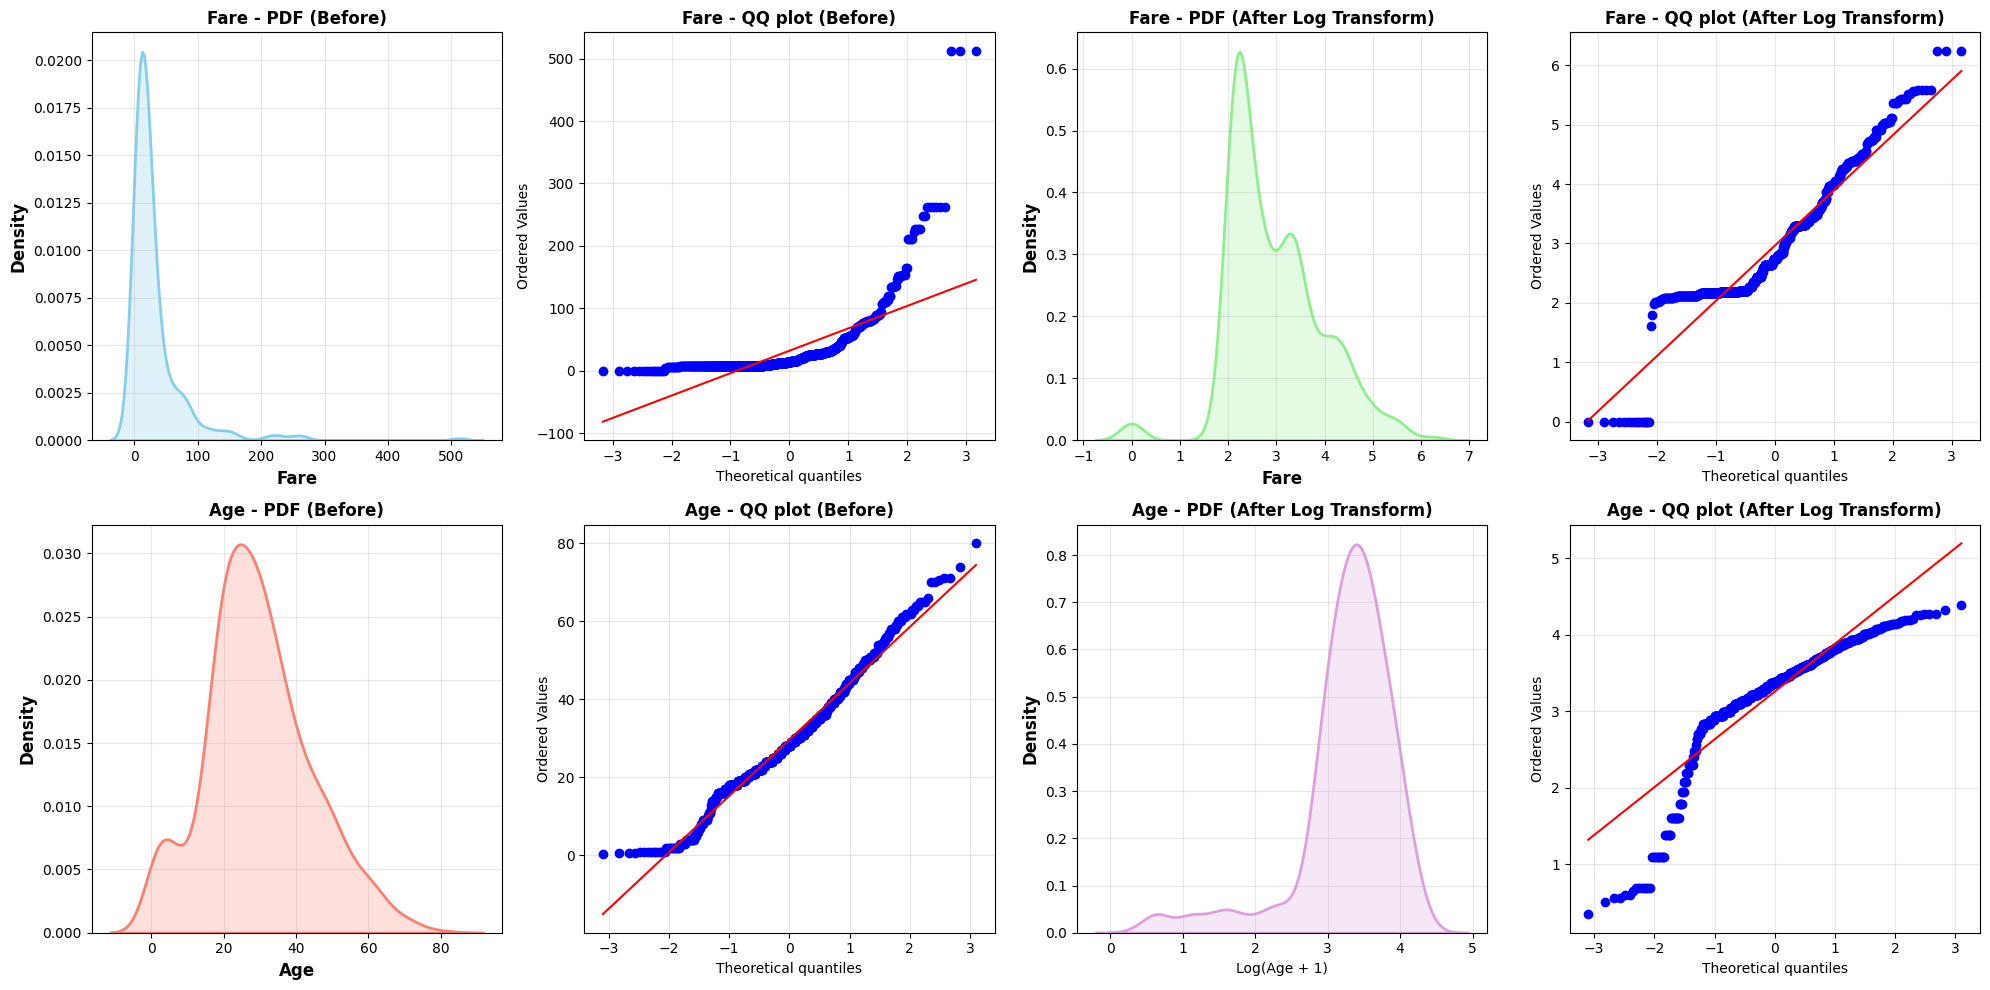

In [268]:
fare_clean = df['Fare'].dropna()
age_clean = df['Age'].dropna()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Fare Analysis
# PDF before 
sns.kdeplot(fare_clean, color='skyblue', fill=True, linewidth=2, ax=axes[0,0])
axes[0, 0].set_title('Fare - PDF (Before)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Fare', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# QQ plot before
stats.probplot(fare_clean, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Fare - QQ plot (Before)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# PDF after 
fare_log = np.log1p(fare_clean)
sns.kdeplot(fare_log, color='lightgreen', fill=True, linewidth=2, ax=axes[0,2])
axes[0, 2].set_title('Fare - PDF (After Log Transform)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Fare', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# QQ plot after
stats.probplot(fare_log, dist='norm', plot=axes[0, 3])
axes[0, 3].set_title('Fare - QQ plot (After Log Transform)', fontsize=12, fontweight='bold')
axes[0, 3].grid(True, alpha=0.3)

# PDF before 
sns.kdeplot(age_clean, color='salmon', fill=True, linewidth=2, ax=axes[1,0])
axes[1, 0].set_title('Age - PDF (Before)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# QQ plot before
stats.probplot(age_clean, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Age - QQ plot (Before)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# PDF after 
age_log = np.log1p(age_clean)
sns.kdeplot(age_log, color='plum', fill=True, linewidth=2, ax=axes[1,2])
axes[1, 2].set_title('Age - PDF (After Log Transform)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Log(Age + 1)')
axes[1, 2].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

# QQ plot after
stats.probplot(age_log, dist='norm', plot=axes[1, 3])
axes[1, 3].set_title('Age - QQ plot (After Log Transform)', fontsize=12, fontweight='bold')
axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [269]:
def log_transform(X):
    """Apply log transformation (adding 1 to avoid log(0))"""
    return np.log1p(X)

In [270]:
fare_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('log', FunctionTransformer(log_transform, validate=True))
])

In [271]:
age_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

In [272]:
preprocessor = ColumnTransformer(
    transformers=[
        ('fare_pipeline', fare_transformer, ['Fare']),
        ('age_pipeline', age_transformer, ['Age']),
], remainder='passthrough'
)

In [273]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

In [274]:
cross_val_score(
    full_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

array([0.61538462, 0.61538462, 0.73943662, 0.66197183, 0.66197183])

In [275]:
print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"Min Accuracy: {cv_scores.min():.4f}")
print(f"Max Accuracy: {cv_scores.max():.4f}")


Cross-Validation Scores: [0.65734266 0.65734266 0.74647887 0.73239437 0.66901408]
Mean Accuracy: 0.6925
Standard Deviation: 0.0388
Min Accuracy: 0.6573
Max Accuracy: 0.7465


In [276]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('fare_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('log',
                                                                   FunctionTransformer(func=<function log_transform at 0x11d10afc0>,
                                                                                       validate=True))]),
                                                  ['Fare']),
                                                 ('age_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['Age'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [277]:
test_score = full_pipeline.score(X_test, y_test)

In [278]:
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
print(f"Test Set Accuracy: {test_score:.4f} ({test_score:.2%})")


TEST SET EVALUATION
Test Set Accuracy: 0.6983 (69.83%)


In [279]:
X_transformed = preprocessor.transform(X_train[:5])
print("\n" + "="*60)
print("SAMPLE TRANSFORMED FEATURES (First 5 Rows from Training Set)")
print("="*60)
print("Original:")
print(X_train.head())
print("\nTransformed (Log(Fare+1), Imputed Age):")
print(pd.DataFrame(X_transformed, columns=['log_fare', 'age']))

print("\n" + "="*60)
print("PIPELINE SUMMARY")
print("="*60)
print("1. Fare: Imputed with median → Log transformed")
print("2. Age: Imputed with mean")
print("3. Model: Random Forest Classifier")
print(f"4. Cross-validation accuracy (training): {cv_scores.mean():.2%}")
print(f"5. Test set accuracy: {test_score:.2%}")


SAMPLE TRANSFORMED FEATURES (First 5 Rows from Training Set)
Original:
      Age     Fare
331  45.5  28.5000
733  23.0  13.0000
382  32.0   7.9250
704  26.0   7.8542
813   6.0  31.2750

Transformed (Log(Fare+1), Imputed Age):
   log_fare   age
0  3.384390  45.5
1  2.639057  23.0
2  2.188856  32.0
3  2.180892  26.0
4  3.474293   6.0

PIPELINE SUMMARY
1. Fare: Imputed with median → Log transformed
2. Age: Imputed with mean
3. Model: Random Forest Classifier
4. Cross-validation accuracy (training): 69.25%
5. Test set accuracy: 69.83%
